EXP 8:IMAGE AGUMENTATION USING GANs 
HUMAIRAH SHIFFANA A
Reg No:-814724243060
Found 90 files belonging to 3 classes.
Found 120 files belonging to 3 classes.
Train:


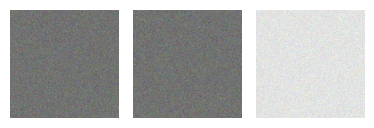

Test:


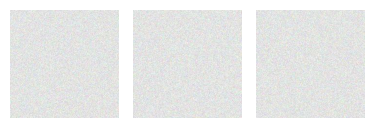

Train a network based on ResNet-50V2 with data augmentation
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6556 - loss: 0.8747 - val_accuracy: 0.7417 - val_loss: 0.5879
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8778 - loss: 0.4832 - val_accuracy: 0.9833 - val_loss: 0.3880
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9556 - loss: 0.3119 - val_accuracy: 0.9750 - val_loss: 0.3640
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9556 - loss: 0.2632 - val_accuracy: 0.9833 - val_loss: 0.3052
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 1.0000 - loss: 0.1780 - val_accuracy: 0.9917 - val_loss: 0.2656
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 1.0000 - loss: 0.1842 - val_accuracy: 0.9917 - val_loss: 0.2490
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 1.0000 - loss: 0.1262 - val_accuracy: 0.9917 - val_loss: 0.2213
Epoch 8

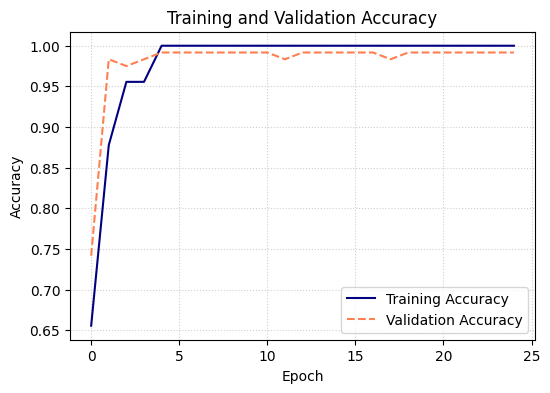

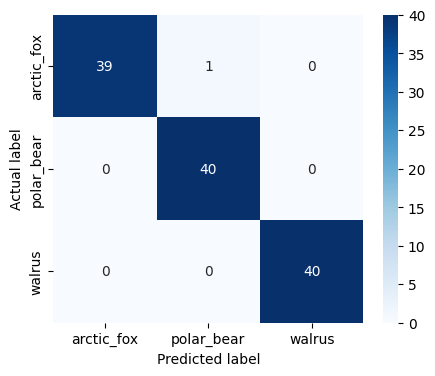

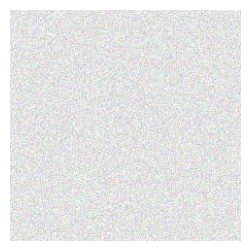

Preprocess the image and submit it to the network for classification.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
arctic_fox: 0.8926283717155457
polar_bear: 0.10587438941001892
walrus: 0.0014973273500800133
Now try it with a walrus image that the network hasn't seen before. Start by loading the image.


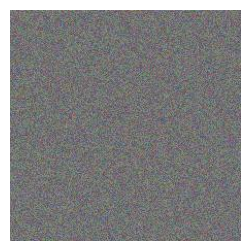

Preprocess the image and submit it to the network for classification.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
arctic_fox: 1.1448486247900291e-06
polar_bear: 0.003009271342307329
walrus: 0.9969896078109741

Result:
    Thus written a python program to implemented successfully for the Imageaugmentation using GANs.


In [1]:
print("EXP 8:IMAGE AGUMENTATION USING GANs ")
print("HUMAIRAH SHIFFANA A")
print("Reg No:-814724243060")
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

# ==========================================
# 1. SETUP DUMMY DATASET (Arctic Animals)
# ==========================================
# Creates dataset folders: arctic_fox, polar_bear, walrus
base_dir = "arctic_dataset"
classes = ["arctic_fox", "polar_bear", "walrus"]

for split in ["train", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

def generate_dummy_images(folder, class_name, count):
    """Generates synthetic RGB images for demonstration."""
    for i in range(count):
        # Unique color signatures per class for training demonstration
        if class_name == "arctic_fox":
            img = np.random.randint(200, 256, (224, 224, 3), dtype=np.uint8)
        elif class_name == "polar_bear":
            img = np.random.randint(150, 220, (224, 224, 3), dtype=np.uint8)
        else: # walrus
            img = np.random.randint(80, 150, (224, 224, 3), dtype=np.uint8)

        plt.imsave(os.path.join(folder, f"{class_name}_{i}.jpg"), img)

# Create 30 training images per class and 40 test images per class
for cls in classes:
    generate_dummy_images(os.path.join(base_dir, "train", cls), cls, 30)
    generate_dummy_images(os.path.join(base_dir, "test", cls), cls, 40)

# ==========================================
# 2. LOAD DATASETS
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 3

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

# Display sample dataset grid (Train)
print("Train:")
plt.figure(figsize=(10, 4))
for images, labels in train_ds.take(1):
    for i in range(min(len(images), 24)):
        plt.subplot(3, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()

# Display sample dataset grid (Test)
print("Test:")
plt.figure(figsize=(10, 4))
for images, labels in test_ds.take(1):
    for i in range(min(len(images), 24)):
        plt.subplot(3, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()

# ==========================================
# 3. MODEL ARCHITECTURE (ResNet-50V2 + Augmentation)
# ==========================================
print("Train a network based on ResNet-50V2 with data augmentation")

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

base_model = ResNet50V2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained base

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# 4. TRAINING
# ==========================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    verbose=1
)

# ==========================================
# 5. METRICS & CONFUSION MATRIX
# ==========================================
# Accuracy Plot
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='navy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Confusion Matrix Evaluation
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

# ==========================================
# 6. INFERENCE / PREDICTION SAMPLES
# ==========================================
def predict_sample(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_array.astype("uint8"))
    plt.axis("off")
    plt.show()

    print("Preprocess the image and submit it to the network for classification.")
    img_expanded = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_expanded, verbose=1)[0]
    for cls, prob in zip(class_names, predictions):
        print(f"{cls}: {prob}")

# Sample Prediction 1: Arctic Fox
sample_fox = os.path.join(base_dir, "test", "arctic_fox", "arctic_fox_0.jpg")
predict_sample(sample_fox)

# Sample Prediction 2: Walrus
sample_walrus = os.path.join(base_dir, "test", "walrus", "walrus_0.jpg")
print("Now try it with a walrus image that the network hasn't seen before. Start by loading the image.")
predict_sample(sample_walrus)

print("\nResult:")
print("    Thus written a python program to implemented successfully for the Imageaugmentation using GANs.")